EDA(Exploritory Data Analysis)

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('synthetic_credit_data_v2.csv')

Basic information about data

In [3]:
df.shape

(10000, 11)

In [4]:
df.head()

,borrower_id,age,occupation,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status
0,BORR00001,52,Small Business Owner,51736.08,63,1,0.250,0,90,0,1
1,BORR00002,56,Kirana Owner,74254.69,82,2,0.094,0,147,0,1
2,BORR00003,57,Kirana Owner,59275.55,66,1,0.102,0,187,0,1
3,BORR00004,34,Kirana Owner,62631.84,82,1,0.286,1,187,0,1
4,BORR00005,47,Driver,22909.49,55,8,0.762,3,42,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   borrower_id               10000 non-null  object 
 1   age                       10000 non-null  int64  
 2   occupation                10000 non-null  object 
 3   monthly_income            10000 non-null  float64
 4   income_consistency_score  10000 non-null  int64  
 5   utility_delay_days        10000 non-null  int64  
 6   debt_to_income_ratio      10000 non-null  float64
 7   active_loans              10000 non-null  int64  
 8   upi_transactions          10000 non-null  int64  
 9   previous_default          10000 non-null  int64  
 10  loan_status               10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [6]:
df.describe()

,age,monthly_income,income_consistency_score,utility_delay_days,debt_to_income_ratio,active_loans,upi_transactions,previous_default,loan_status
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,40.399000,36978.500621,72.597700,1.983100,0.332028,0.868900,152.844700,0.14770,0.785500
std,11.511961,16635.934493,15.733519,2.554421,0.198705,0.993082,43.419437,0.35482,0.410496
min,21.000000,10410.770000,5.000000,0.000000,0.020000,0.000000,5.000000,0.00000,0.000000
25%,30.000000,23616.337500,66.000000,0.000000,0.209000,0.000000,124.000000,0.00000,1.000000
50%,40.000000,32420.130000,75.000000,1.000000,0.271000,1.000000,157.000000,0.00000,1.000000
75%,50.000000,49256.072500,83.000000,2.000000,0.357250,1.000000,183.000000,0.00000,1.000000
max,60.000000,86824.970000,100.000000,19.000000,0.980000,4.000000,296.000000,1.00000,1.000000


In [7]:
df.isnull().sum()

borrower_id                 0
age                         0
occupation                  0
monthly_income              0
income_consistency_score    0
utility_delay_days          0
debt_to_income_ratio        0
active_loans                0
upi_transactions            0
previous_default            0
loan_status                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df['loan_status'].value_counts()

1    7855
0    2145
Name: loan_status, dtype: int64

Track default history

In [10]:
pd.crosstab(
    df['previous_default'],
    df['loan_status'],
    normalize='index')

loan_status,0,1
previous_default,,
0,0.162032,0.837968
1,0.517265,0.482735


Graphical Representation

In [11]:
import seaborn as sns

<AxesSubplot:xlabel='loan_status', ylabel='debt_to_income_ratio'>

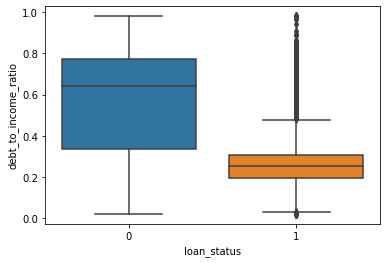

In [12]:
sns.boxplot(
    x='loan_status',
    y='debt_to_income_ratio',
    data=df)

<AxesSubplot:xlabel='loan_status', ylabel='monthly_income'>

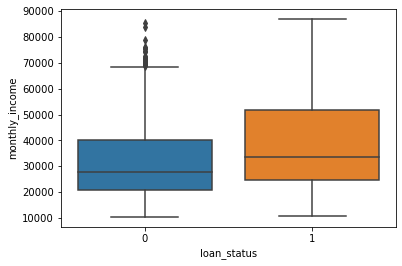

In [13]:
sns.boxplot(
    x='loan_status',
    y='monthly_income',
    data=df)

<AxesSubplot:xlabel='loan_status', ylabel='utility_delay_days'>

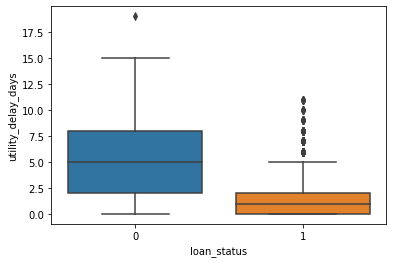

In [14]:
sns.boxplot(
    x='loan_status',
    y='utility_delay_days',
    data=df)


Introduction of new terminology and its relation

In [15]:
df['financial_stress']=(
    df['debt_to_income_ratio']*(df['active_loans']+1))
df['financial_stress']

0       0.250
1       0.094
2       0.102
3       0.572
4       3.048
        ...  
9995    0.252
9996    0.257
9997    0.225
9998    0.208
9999    0.199
Name: financial_stress, Length: 10000, dtype: float64

In [16]:
df['income_per_loan']=(df['monthly_income']/(df['active_loans']+1))
df['income_per_loan']

0       51736.0800
1       74254.6900
2       59275.5500
3       31315.9200
4        5727.3725
           ...    
9995    25901.2100
9996    63210.8300
9997    45634.1800
9998    24100.0700
9999    18461.3600
Name: income_per_loan, Length: 10000, dtype: float64

In [17]:
df['risk_history']=(df['previous_default']*df['utility_delay_days'])
df['risk_history']

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: risk_history, Length: 10000, dtype: int64

In [18]:
pd.crosstab(
    df['occupation'],
    df['loan_status'],
    normalize='index').sort_values(1)

loan_status,0,1
occupation,,
Delivery Partner,0.249480,0.750520
Driver,0.223606,0.776394
Freelancer,0.211656,0.788344
Kirana Owner,0.198304,0.801696
Small Business Owner,0.180268,0.819732


In [19]:
occupation_risk={
    'Delivery Partner': 0.249,
    'Driver': 0.224,
    'Freelancer': 0.212,
    'Kirana Owner': 0.198,
    'Small Business Owner': 0.180}

In [20]:
df['occupation_risk']=(
    df['occupation'].map(occupation_risk))

In [21]:
df['high_risk_flag']=(
    (df['previous_default']==1)
    &
    (df['debt_to_income_ratio']>0.5)).astype(int)
df['high_risk_flag']

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: high_risk_flag, Length: 10000, dtype: int64

It suggests that borrowers with previous default history have greater default possibilities.

Using ColumnTransformer and Pipeline

In [22]:
numerical_cols = [
    'age',
    'monthly_income',
    'income_consistency_score',
    'utility_delay_days',
    'debt_to_income_ratio',
    'active_loans',
    'upi_transactions',
    'previous_default',
    'financial_stress',
    'income_per_loan',
    'risk_history',
    'occupation_risk',
    'high_risk_flag'
]
categorical_cols = [
    'occupation']

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [26]:
num_pipeline=Pipeline([
    ('imputer',
     SimpleImputer(strategy='median')),
    ('scaler',
     StandardScaler())])
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [27]:
cat_pipeline=Pipeline([
    ('imputer',
     SimpleImputer(strategy='most_frequent')),
    ('encoder',
     OneHotEncoder(handle_unknown='ignore'))])
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [28]:
preprocessor=ColumnTransformer([
    ('num',
     num_pipeline,
     numerical_cols),
    ('cat',
     cat_pipeline,
     categorical_cols)])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'monthly_income',
                                  'income_consistency_score',
                                  'utility_delay_days', 'debt_to_income_ratio',
                                  'active_loans', 'upi_transactions',
                                  'previous_default', 'financial_stress',
                                  'income_per_loan', 'risk_history',
                                  'occupation_risk', 'high_risk_flag']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['occupation'])])

Creating Labels and Features

In [29]:
X = df.drop('loan_status', axis=1)
Y = df['loan_status']

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [31]:
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

In [32]:
from imblearn.over_sampling import SMOTE

Applying SMOTE

In [33]:
smote=SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(
    X_train_processed,
    Y_train
)

/home/8532ab48-7061-4378-988e-635a9bc35ff0/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/8532ab48-7061-4378-988e-635a9bc35ff0/.local/lib/python3.9/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/home/8532ab48-7061-4378-988e-635a9bc35ff0/.local/lib/python3.9/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Applying LogisticRegression

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
lr=LogisticRegression(random_state=42,
                      max_iter=1000)
lr.fit( X_train_processed,
    Y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [36]:
prediction=lr.predict(X_test_processed)

In [37]:
from sklearn.metrics import classification_report
classification_report(Y_test,prediction)

'              precision    recall  f1-score   support\n\n           0       0.86      0.69      0.76       429\n           1       0.92      0.97      0.94      1571\n\n    accuracy                           0.91      2000\n   macro avg       0.89      0.83      0.85      2000\nweighted avg       0.91      0.91      0.90      2000\n'

Applying LogisticRegression and SMOTE

In [38]:
lr1=LogisticRegression(random_state=42,
                      max_iter=1000)
lr1.fit(X_train_balanced, Y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [39]:
prediction3=lr1.predict(X_test_processed)

In [40]:
from sklearn.metrics import classification_report
classification_report(Y_test,prediction3)

'              precision    recall  f1-score   support\n\n           0       0.83      0.72      0.77       429\n           1       0.93      0.96      0.94      1571\n\n    accuracy                           0.91      2000\n   macro avg       0.88      0.84      0.85      2000\nweighted avg       0.90      0.91      0.90      2000\n'

Applying RandomForestClassifier

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rf=RandomForestClassifier(random_state=42)
rf.fit( X_train_processed,
    Y_train)

RandomForestClassifier(random_state=42)

In [43]:
prediction1=rf.predict(X_test_processed)

In [44]:
classification_report(
    Y_test,
    prediction1)

'              precision    recall  f1-score   support\n\n           0       0.85      0.68      0.76       429\n           1       0.92      0.97      0.94      1571\n\n    accuracy                           0.91      2000\n   macro avg       0.89      0.82      0.85      2000\nweighted avg       0.90      0.91      0.90      2000\n'

Applying RandomForestClassifier and SMOTE

In [45]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train_balanced, Y_train_balanced)

RandomForestClassifier(random_state=42)

In [46]:
prediction4=rf.predict(X_test_processed)

In [47]:
classification_report(
    Y_test,prediction4)

'              precision    recall  f1-score   support\n\n           0       0.82      0.69      0.75       429\n           1       0.92      0.96      0.94      1571\n\n    accuracy                           0.90      2000\n   macro avg       0.87      0.82      0.84      2000\nweighted avg       0.90      0.90      0.90      2000\n'

Applying XGBoost

In [48]:
from xgboost import XGBClassifier

In [49]:
xgb=XGBClassifier(
    random_state=42,
    eval_metric='logloss')
xgb.fit(  X_train_processed,
    Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [50]:
prediction2=xgb.predict(X_test_processed)
prediction2

array([1, 1, 0, ..., 1, 1, 1])

In [51]:
from sklearn.metrics import classification_report

In [52]:
classification_report(Y_test,prediction2)

'              precision    recall  f1-score   support\n\n           0       0.83      0.66      0.73       429\n           1       0.91      0.96      0.94      1571\n\n    accuracy                           0.90      2000\n   macro avg       0.87      0.81      0.83      2000\nweighted avg       0.89      0.90      0.89      2000\n'

Applying Catboost

In [53]:
from catboost import CatBoostClassifier

In [54]:
cat=CatBoostClassifier(
    random_state=42,
    verbose=0)
cat.fit( X_train_processed, Y_train) 

CatBoostClassifier(random_state=42, verbose=0)

In [55]:
prediction5=cat.predict(X_test_processed)

In [56]:
classification_report(Y_test,prediction5)

'              precision    recall  f1-score   support\n\n           0       0.86      0.68      0.76       429\n           1       0.92      0.97      0.94      1571\n\n    accuracy                           0.91      2000\n   macro avg       0.89      0.83      0.85      2000\nweighted avg       0.91      0.91      0.90      2000\n'

After comparing different models we conclude that LogisticRegression with SMOTE performs better relative to other

Applying SHAP to explain the reason behind any outcomes we get

In [57]:
import shap

In [58]:
explainer=shap.LinearExplainer(lr1,X_train_balanced)

In [59]:
shap_values=explainer.shap_values(
    X_test_processed)

In [60]:
feature_names=(preprocessor.get_feature_names_out())
feature_names

array(['num__age', 'num__monthly_income', 'num__income_consistency_score',
       'num__utility_delay_days', 'num__debt_to_income_ratio',
       'num__active_loans', 'num__upi_transactions',
       'num__previous_default', 'num__financial_stress',
       'num__income_per_loan', 'num__risk_history',
       'num__occupation_risk', 'num__high_risk_flag',
       'cat__occupation_Delivery Partner', 'cat__occupation_Driver',
       'cat__occupation_Freelancer', 'cat__occupation_Kirana Owner',
       'cat__occupation_Small Business Owner'], dtype=object)

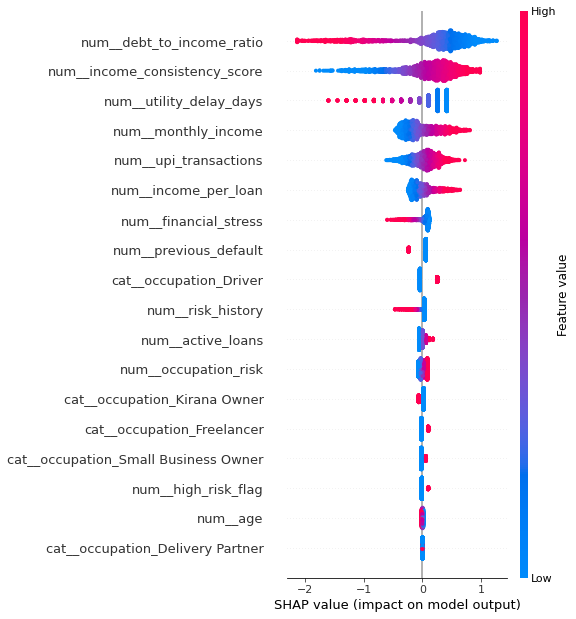

In [61]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names)

Deploying 

In [64]:
import joblib
joblib.dump(lr1, 'model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']